In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#import copula functions
from pr_copula.main_copula_regression_conditional import fit_copula_cregression,predict_copula_cregression,predictive_resample_cregression,check_convergence_pr_cregression

from copula_mp import mp_density, mp_density_t_learner, mp_density_att
from copula_mp_iv import mp_density_iv, mp_compliers

## The effect of Zinc supplementation on the duration of the common cold

In [25]:
# load data
d = pd.read_csv("Data/ZnAcet.csv")

y = d.Duration.values
x = d.Zinc.values
w = np.ones(len(y))

# compute standardisation parameters and standardise y
mu_y = y.mean()
sig_y = y.std()
y_std = (y - mu_y) / sig_y

# run analysis — grid on standardised scale
T = 5000
B = 500

y_grid_orig = np.linspace(0, 18, 50)
y_grid_std = (y_grid_orig - mu_y) / sig_y

# single learner approach
res = mp_density(y_std, x, w, [0, 1], y_grid_std, B, T)

# twin learner approach
res_t = mp_density_t_learner(y_std, x, w, [0, 1], y_grid_std, B, T)



Compiling...
Compilation time: 2.464s
Optimizing...
Optimization time: 1.131s
Fitting...
Fit time: 0.027s
Optimised rho:  0.60132074
Optimised rho_x:  [0.8401232  0.00619007]
Prequential log-likelihhod:  -1.2659235000610352
Predicting...
Prediction time: 0.457s
Predictive resampling...
Predictive resampling time: 8.777s
Compiling...
Compilation time: 1.683s
Optimizing...
Optimization time: 0.27s
Fitting...
Fit time: 0.004s
Optimised rho for x=0:  0.6701834
Optimised rho_x for x=0:  [0.04114372 0.00157737]
Prequential log-likelihood for x=0:  -1.4737317562103271
Predicting...
Prediction time: 0.418s
Predictive resampling...
Predictive resampling time: 6.179s
Compiling...
Compilation time: 1.82s
Optimizing...
Optimization time: 0.361s
Fitting...
Fit time: 0.005s
Optimised rho for x=1:  0.71388704
Optimised rho_x for x=1:  [0.00402309 0.00402309]
Prequential log-likelihood for x=1:  -1.068336009979248
Predicting...
Prediction time: 0.386s
Predictive resampling...
Predictive resampling tim

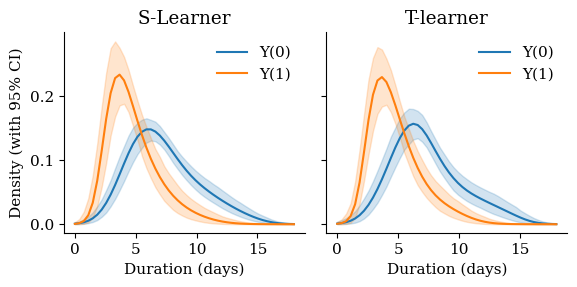

In [27]:

fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharey=True)

plt.rcParams.update({
    "font.family":      "serif",
    "font.size":        11,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.linewidth":   0.8,
    "xtick.direction":  "out",
    "ytick.direction":  "out",
})

# --- Panel 1: S-Learner ---
ax = axes[0]
ax.plot(y_grid_orig, res['x_0']['mean'] / sig_y, label="Y(0)", color='tab:blue')
ax.fill_between(y_grid_orig, res['x_0']['low'] / sig_y, res['x_0']['high'] / sig_y, color='tab:blue', alpha=0.2)
ax.plot(y_grid_orig, res['x_1']['mean'] / sig_y, label="Y(1)", color='tab:orange')
ax.fill_between(y_grid_orig, res['x_1']['low'] / sig_y, res['x_1']['high'] / sig_y, color='tab:orange', alpha=0.2)
ax.set_xlabel("Duration (days)")
ax.set_ylabel("Density (with 95% CI)")
ax.set_title("S-Learner")
ax.legend(frameon=False)

# --- Panel 2: T-learner ---
ax = axes[1]
ax.plot(y_grid_orig, res_t['x_0']['mean'] / sig_y, label="Y(0)", color='tab:blue')
ax.fill_between(y_grid_orig, res_t['x_0']['low'] / sig_y, res_t['x_0']['high'] / sig_y, color='tab:blue', alpha=0.2)
ax.plot(y_grid_orig, res_t['x_1']['mean'] / sig_y, label="Y(1)", color='tab:orange')
ax.fill_between(y_grid_orig, res_t['x_1']['low'] / sig_y, res_t['x_1']['high'] / sig_y, color='tab:orange', alpha=0.2)
ax.set_xlabel("Duration (days)")
ax.set_title("T-learner")
ax.legend(frameon=False)

plt.tight_layout()
plt.savefig('Figures/ZincExample.pdf', dpi=300, bbox_inches='tight')
plt.show()


## A Vitamin A supplementation trial

In [2]:
# Sommer & Zeger Vitamin A Study Dataset
# Create the dataset from contingency table
data_counts = [
    (0, 0, 0, 74),      # Assigned: No, Received: No, Outcome: Died
    (0, 0, 1, 11514),   # Assigned: No, Received: No, Outcome: Survived
    (1, 0, 0, 34),      # Assigned: Yes, Received: No, Outcome: Died
    (1, 0, 1, 2385),    # Assigned: Yes, Received: No, Outcome: Survived
    (1, 1, 0, 12),      # Assigned: Yes, Received: Yes, Outcome: Died
    (1, 1, 1, 9663)     # Assigned: Yes, Received: Yes, Outcome: Survived
]

Z_data = []
X_data = []
Y_data = []

for z, x, y, count in data_counts:
    Z_data.extend([z] * count)
    X_data.extend([x] * count)
    Y_data.extend([y] * count)

Z_data = np.array(Z_data)
X_data = np.array(X_data)
Y_data = np.array(Y_data)

print(f"Total observations: {len(Y_data)}")
print(f"Outcome distribution: {np.mean(Y_data):.4f}")
print(f"Treatment (X=1) rate: {np.mean(X_data):.4f}")
print(f"Instrument (Z=1) rate: {np.mean(Z_data):.4f}")

# Summary statistics by instrument assignment
print("\nSummary by Instrument Assignment:")
print(f"  Z=0: P(X=1|Z=0) = {np.mean(X_data[Z_data == 0]):.4f}")
print(f"  Z=1: P(X=1|Z=1) = {np.mean(X_data[Z_data == 1]):.4f}")

Total observations: 23682
Outcome distribution: 0.9949
Treatment (X=1) rate: 0.4085
Instrument (Z=1) rate: 0.5107

Summary by Instrument Assignment:
  Z=0: P(X=1|Z=0) = 0.0000
  Z=1: P(X=1|Z=1) = 0.8000


In [3]:
# Run mp_compliers with Bayesian bootstrap approach
# For binary outcomes with complier identification
B_post = 1000  # Number of posterior samples
T_fwd = 100000 - len(Y_data)

np.random.seed(42)
results_compliers = mp_compliers(Y_data, X_data, Z_data, B_post, T_fwd)

In [23]:
# report the comlier proportion
print("90% CI for the complier proportion: ", np.quantile(results_compliers['Complier'], [0.05, 0.95]))

# report the LATE estimates
print(
    "90% CI for the LATE (per 1000 individuals): ",
    1000 * np.quantile(results_compliers['Treatment'] - results_compliers['Control'], [0.05, 0.95])
)

90% CI for the complier proportion:  [0.79487741 0.80521985]
90% CI for the LATE (per 1000 individuals):  [1.56763243 4.84062739]


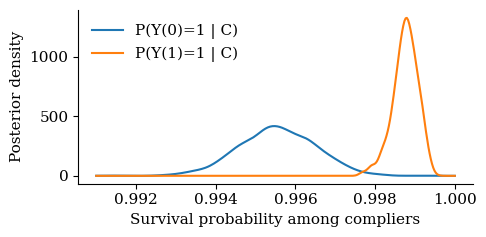

In [25]:
from scipy.stats import gaussian_kde

p_y0_samples = results_compliers['Control']
p_y1_samples = results_compliers['Treatment']

plt.rcParams.update({
    "font.family":      "serif",
    "font.size":        11,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.linewidth":   0.8,
    "xtick.direction":  "out",
    "ytick.direction":  "out",
})

fig, ax = plt.subplots(figsize=(5, 2.5))

for samples, label in [(p_y0_samples, 'P(Y(0)=1 | C)'), (p_y1_samples, 'P(Y(1)=1 | C)')]:
    kde = gaussian_kde(samples)
    x = np.linspace(0.991, 1, 300)
    ax.plot(x, kde(x), label=label)

ax.set_xlabel('Survival probability among compliers')
ax.set_ylabel('Posterior density')
ax.legend(frameon = False)
plt.tight_layout()
plt.savefig("Figures/Sommer_Zeger_Results.pdf")
plt.show()

## Lalonde

In [2]:
# load data
d = pd.read_csv("Data/lalonde.csv")

y = np.log(d.re78.values + 1)
x = d.treat.values
w = d[['age', 'educ', 'hisp', 'black', 'married', 'nodegr', 're74', 're75', 'u74', 'u75']].values

In [13]:

# compute standardisation parameters and standardise y
mu_y = y.mean()
sig_y = y.std()
y_std = (y - mu_y) / sig_y

w_std = (w - w.mean(axis=0)) / w.std(axis=0)

# run analysis — grid on standardised scale
T = 2000
B = 200

y_grid_orig = np.linspace(y.min(), y.max(), 50)
y_grid_std = (y_grid_orig - mu_y) / sig_y

# Control counterfactual outcome among treated Y(0)|X = 1
res_tt = mp_density_att(y_std, x, w_std, y_grid_std, B, T)

# Unconditional control counterfactual outcome Y(0)
res_unc = mp_density(y_std, x, w_std, [0], y_grid_std, B, T)


Compiling...
Compilation time: 0.485s
Optimizing...
Optimization time: 8.627s
Fitting...
Fit time: 0.071s
Optimised rho:  0.14019004
Optimised rho_x:  [0.93271375 0.57584417 0.66281116 0.19079581 0.51830924 0.01678767
 0.01715813 0.7148587  0.03322973 0.23519616 0.36699843]
Prequential log-likelihhod:  -1.4007147550582886
Predicting...
Prediction time: 1.086s
Predictive resampling...
Predictive resampling time: 34.615s
Compiling...
Compilation time: 0.63s
Optimizing...
Optimization time: 9.435s
Fitting...
Fit time: 0.063s
Optimised rho:  0.14019004
Optimised rho_x:  [0.93271375 0.57584417 0.66281116 0.19079581 0.51830924 0.01678767
 0.01715813 0.7148587  0.03322973 0.23519616 0.36699843]
Prequential log-likelihhod:  -1.4007147550582886
Predicting...
Prediction time: 2.282s
Predictive resampling...
Predictive resampling time: 83.946s


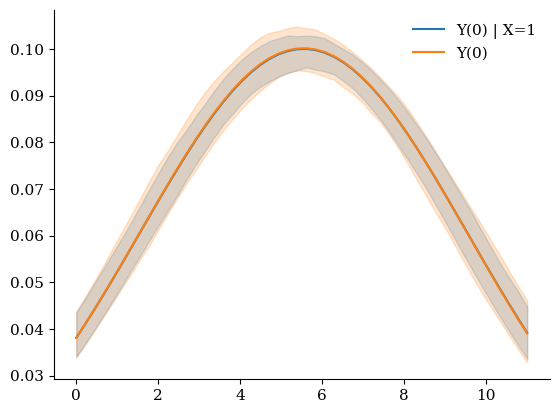

In [14]:
plt.rcParams.update({
    "font.family":      "serif",
    "font.size":        11,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.linewidth":   0.8,
    "xtick.direction":  "out",
    "ytick.direction":  "out",
})

plt.plot(y_grid_orig, res_tt['x_0']['mean'] / sig_y, label = "Y(0) | X=1")
plt.fill_between(y_grid_orig, res_tt['x_0']['low'] / sig_y, res_tt['x_0']['high'] / sig_y, color='tab:blue', alpha=0.2)

plt.plot(y_grid_orig, res_unc['x_0']['mean'] / sig_y, label = "Y(0)")
plt.fill_between(y_grid_orig, res_unc['x_0']['low'] / sig_y, res_unc['x_0']['high'] / sig_y, color='tab:orange', alpha=0.2)
plt.legend(frameon=False)